### Code funzionante

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
from random import randrange
import random

In [3]:
bits = 64

In [4]:
for _ in range(19):
    b = random.getrandbits(bits)

    MANTISSA_BITS = 8
    LUT_SIZE = 1 << MANTISSA_BITS  # 256
    scale4 = 1 << (4 * bits)

    s = bits - b.bit_length()
    s += s & 1
    b_norm = b << s

    raw = (b_norm >> (bits - MANTISSA_BITS - 1)) - LUT_SIZE  # [0, 768)
    window = raw >> MANTISSA_BITS   # 0, 1, o 2
    mantissa = raw & (LUT_SIZE - 1) # [0, 256)
    
    print(window)

    lut = [
        [math.isqrt(scale4 // ((LUT_SIZE + w * LUT_SIZE + i) << (bits - MANTISSA_BITS - 1)))
         for i in range(LUT_SIZE)]
        for w in range(3)
    ]

    # selezione oblivious: nessun branch
    x0 = lut[0][mantissa]
    x1 = lut[1][mantissa]
    x2 = lut[2][mantissa]
    f0 = 1 - min(window, 1)          # 1 se window==0, else 0
    f2 = window >> 1                 # 1 se window==2, else 0
    f1 = 1 - f0 - f2                 # 1 se window==1, else 0
    x = f0 * x0 + f1 * x1 + f2 * x2

    P = 2 * bits
    for _ in range(2):
        t = (b_norm * x * x) >> P
        x = (x * (3 * (1 << P) - t)) >> (P + 1)

    result = (b * x) >> (P - s // 2)
    print("My res:", result)
    print("Expect:", math.isqrt(b))
    
    if result != math.isqrt(b):
        print("A!")
    #print("***")

0
My res: 3098174652
Expect: 3098174652
1
My res: 2232206135
Expect: 2232206135
0
My res: 2104273867
Expect: 2104273867
0
My res: 4070638976
Expect: 4070638976
0
My res: 1922797193
Expect: 1922797193
0
My res: 4109730548
Expect: 4109730548
2
My res: 2813828127
Expect: 2813828127
0
My res: 3642884391
Expect: 3642884391
0
My res: 3530358238
Expect: 3530358238
0
My res: 3290179845
Expect: 3290179845
0
My res: 1889141589
Expect: 1889141589
0
My res: 3164223232
Expect: 3164223232
0
My res: 3838166403
Expect: 3838166403
0
My res: 2004738242
Expect: 2004738242
2
My res: 2991347924
Expect: 2991347924
0
My res: 3046248364
Expect: 3046248364
0
My res: 3444606435
Expect: 3444606435
0
My res: 469761143
Expect: 469761143
2
My res: 671391643
Expect: 671391643


In [163]:
2**9

512

In [159]:
# Debug: verifica il range reale di idx
idxs = []
for _ in range(100000):
    b = random.getrandbits(bits)
    s = bits - b.bit_length()
    s += s & 1
    b_norm = b << s
    idx = (b_norm >> (bits - LUT_BITS - 1)) - LUT_SIZE
    idxs.append(idx)
print(min(idxs), max(idxs))

0 767


### Todo: map the LUT as a polynomial

In [42]:
def get_bit(n, i):
    return (n >> i) & 1

In [43]:
def polylut(bit = 0):
    N = LUT_SIZE
    seq = np.array([get_bit(lut[i], bit) for i in range(N)], dtype=float)
    c = np.fft.fft(seq)  

    def f(x):
        s = 0.0
        for k in range(N):
            ang = 2 * math.pi * k * x / N
            s += c[k].real * math.cos(ang) - c[k].imag * math.sin(ang)
        return s / N

    return f

In [44]:
class Chebyshev:
    """
    Chebyshev(a, b, n, func)
    Given a function func, lower and upper limits of the interval [a,b],
    and maximum degree n, this class computes a Chebyshev approximation
    of the function.
    Method eval(x) yields the approximated function value.
    """
    def __init__(self, a, b, n, func):
        n = n + 1
        self.a = a
        self.b = b
        self.func = func

        bma = 0.5 * (b - a)
        bpa = 0.5 * (b + a)
        f = [func(math.cos(math.pi * (k + 0.5) / n) * bma + bpa) for k in range(n)]
        self.roots = f

        self.x = [math.cos(math.pi * (k + 0.5) / n) * bma + bpa for k in range(n)]

        fac = 2.0 / n
        self.c = [fac * sum([f[k] * math.cos(math.pi * j * (k + 0.5) / n)
                  for k in range(n)]) for j in range(n)]

    def eval(self, x):
        a,b = self.a, self.b
        #assert(a <= x <= b)
        y = (2.0 * x - a - b) * (1.0 / (b - a))
        y2 = 2.0 * y
        (d, dd) = (self.c[-1], 0)             # Special case first step for efficiency
        for cj in self.c[-2:0:-1]:            # Clenshaw's recurrence
            (d, dd) = (y2 * d - dd + cj, d)
        return y * d - dd + 0.5 * self.c[0]   # Last step is different

In [45]:
lut[0].bit_length()

97

In [46]:
if False:
    polyluts = []

    for bit in range(lut[0].bit_length()):
        f = polylut(bit)

        c = Chebyshev(0, LUT_SIZE, 851, f)

        polyluts.append(c)

0.6282424748106306

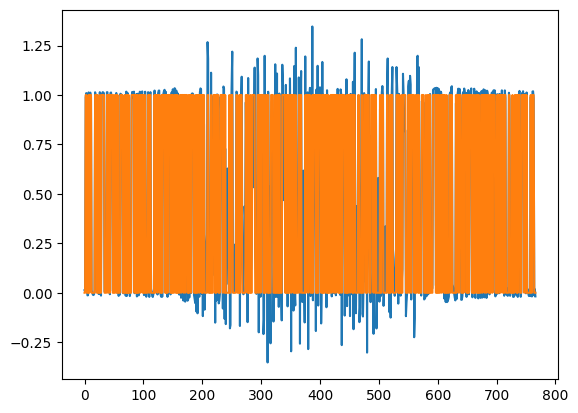

In [140]:
f = polylut(0)

c = Chebyshev(0, 767, 2001, f)

x = np.arange(0, 767, 1)

y = np.vectorize(c.eval)(x)
plt.plot(x, y)

y_real = np.vectorize(f)(x)
plt.plot(x, y_real)


max(abs(y - y_real))

---

### Making the LUT polynomial

In [55]:
s = bits - b.bit_length()
s += s & 1         
b_norm = b << s  

idx = (b_norm >> (bits - LUT_BITS - 1)) - LUT_SIZE 
idx

439

In [56]:
binx = []

for i in range(bits * 2):
    if i >= len(polyluts):
        binx.append(0)
    else:
        binx.append(polyluts[i].eval(idx))

/var/folders/f4/cjlhwcw50v97ltsgj1fxyssm0000gn/T/ipykernel_5340/2829239332.py:33: RuntimeWarning: overflow encountered in scalar multiply
  (d, dd) = (y2 * d - dd + cj, d)
/var/folders/f4/cjlhwcw50v97ltsgj1fxyssm0000gn/T/ipykernel_5340/2829239332.py:33: RuntimeWarning: invalid value encountered in scalar subtract
  (d, dd) = (y2 * d - dd + cj, d)


In [54]:
polydec = ([round(x) for x in list(binx)][::-1])

ValueError: cannot convert float NaN to integer

In [37]:
n = int("".join(map(str, polydec)), 2)

# We check that the polynomial LUT and the actual LUT are equal
n == lut[idx]

True

In [38]:
lut[idx]

96238717494616424696031144974

In [28]:
x = n

# Newton-Raphson — still 4 iterations, initial quality is identical
P = 2 * bits

print(x)
for _ in range(4):
    t = (b_norm * x * x) >> P
    x = (x * (3 * (1 << P) - t)) >> (P + 1)

result = (b * x) >> (P - s // 2)

print("Result:", result)
print("Expect:", math.isqrt(b))


96238717494616424696031144974
Result: 152630
Expect: 152719
